In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
# Parameters
D = 0.001       # known diffusion coefficient
k_true = 0.01  # TRUE reaction rate — what we want to recover

# Spatial and time grid
Nx = 50
Nt = 100
x_np = np.linspace(0, 1, Nx)
t_np = np.linspace(0, 1, Nt)

# Initial condition: u(x, 0) = sin(πx)
u0 = np.sin(np.pi * x_np)

# Discretize PDE using finite differences in space
# du/dt = D * u_xx - k * u
def pde_rhs(t, u):
    dx = x_np[1] - x_np[0]
    # Second derivative via finite differences
    u_xx = np.zeros_like(u)
    u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    # Boundary conditions: u(0,t) = u(1,t) = 0
    u_xx[0]  = 0
    u_xx[-1] = 0
    return D * u_xx - k_true * u

# Solve ODE system (method of lines)
sol = solve_ivp(pde_rhs, [0, 1], u0, t_eval=t_np, method='RK45', dense_output=True)

# u_grid shape: (Nx, Nt)
u_grid = sol.y   # sol.y has shape (Nx, Nt)

print(f"Ground truth shape: {u_grid.shape}")
print(f"u min: {u_grid.min():.4f}, max: {u_grid.max():.4f}")

Ground truth shape: (50, 100)
u min: 0.0000, max: 0.9995


In [4]:
N_obs = 100
np.random.seed(42)

# Random indices in space and time
idx_x = np.random.randint(0, Nx, N_obs)
idx_t = np.random.randint(0, Nt, N_obs)

x_obs_np = x_np[idx_x]
t_obs_np = t_np[idx_t]
u_obs_np = u_grid[idx_x, idx_t]

# Convert to tensors
x_obs = torch.FloatTensor(x_obs_np).reshape(-1, 1)
t_obs = torch.FloatTensor(t_obs_np).reshape(-1, 1)
u_obs = torch.FloatTensor(u_obs_np).reshape(-1, 1)

print(f"Observation points: {x_obs.shape}")
print(f"u_obs min: {u_obs.min():.4f}, max: {u_obs.max():.4f}")

Observation points: torch.Size([100, 1])
u_obs min: 0.0000, max: 0.9979


In [5]:
N_f = 5000
x_f = torch.FloatTensor(N_f, 1).uniform_(0, 1)
t_f = torch.FloatTensor(N_f, 1).uniform_(0, 1)

# Initial condition
N_ic = 100
x_ic = torch.FloatTensor(Nx, 1)
x_ic[:, 0] = torch.FloatTensor(x_np)
t_ic = torch.zeros(Nx, 1)
u_ic = torch.FloatTensor(u0).reshape(-1, 1)

# Boundary conditions: u(0,t) = u(1,t) = 0
N_bc = 100
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1)
x_bc = torch.cat([torch.zeros(N_bc//2, 1), torch.ones(N_bc//2, 1)], dim=0)
u_bc = torch.zeros(N_bc, 1)

In [6]:
class PINN(nn.Module):
    def __init__(self, layers=[2, 64, 64, 64, 64, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

model = PINN()

# k is unknown — treated as trainable parameter
k = torch.nn.Parameter(torch.tensor([0.5]))  # initial guess

# Optimize both network weights AND k
optimizer = torch.optim.Adam(list(model.parameters()) + [k], lr=1e-3)

print(f"Initial k guess: {k.item():.4f}  (true k = {k_true})")

Initial k guess: 0.5000  (true k = 0.01)


In [7]:
def compute_loss():
    # PDE residual
    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    # uₜ = D·u_xx − k·u
    residual = u_t - D * u_xx + k * u
    loss_pde = torch.mean(residual**2)

    # Data loss — match observations
    u_pred_obs = model(x_obs, t_obs)
    loss_data = torch.mean((u_pred_obs - u_obs)**2)

    # Initial condition
    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    # Boundary condition
    u_pred_bc = model(x_bc, t_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    return loss_pde + 10 * loss_data + 10 * loss_ic + 10 * loss_bc

In [8]:
losses = []
k_history = []

for epoch in range(10000):
    optimizer.zero_grad()
    loss = compute_loss()
    loss.backward()
    optimizer.step()

    # Force k to stay positive
    with torch.no_grad():
        k.clamp_(min=1e-6)

    losses.append(loss.item())
    k_history.append(k.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | k estimate: {k.item():.6f}")

print(f"\nTrue k:      {k_true}")
print(f"Recovered k: {k.item():.6f}")
print(f"Relative error: {abs(k.item() - k_true)/k_true * 100:.2f}%")

Epoch     0 | Loss: 9.067166 | k estimate: 0.499000
Epoch  1000 | Loss: 0.004052 | k estimate: 0.028864
Epoch  2000 | Loss: 0.000236 | k estimate: 0.012609
Epoch  3000 | Loss: 0.000269 | k estimate: 0.011267
Epoch  4000 | Loss: 0.000128 | k estimate: 0.010941
Epoch  5000 | Loss: 0.013573 | k estimate: 0.010695
Epoch  6000 | Loss: 0.000077 | k estimate: 0.010596
Epoch  7000 | Loss: 0.000043 | k estimate: 0.010626
Epoch  8000 | Loss: 0.000049 | k estimate: 0.010557
Epoch  9000 | Loss: 0.000108 | k estimate: 0.010475

True k:      0.01
Recovered k: 0.010988
Relative error: 9.88%


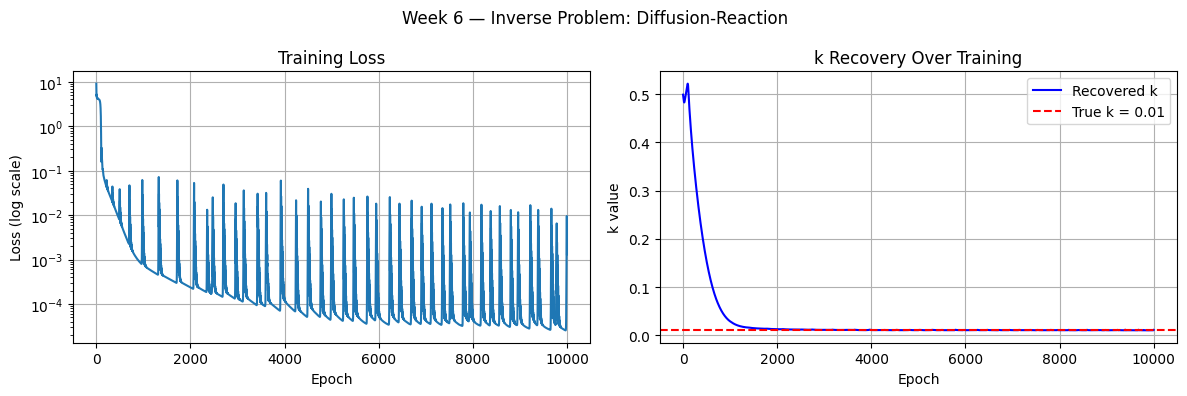

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(k_history, label='Recovered k', color='blue')
ax2.axhline(y=k_true, color='red', linestyle='--', label=f'True k = {k_true}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('k value')
ax2.set_title('k Recovery Over Training')
ax2.legend()
ax2.grid(True)

plt.suptitle('Week 6 — Inverse Problem: Diffusion-Reaction')
plt.tight_layout()
plt.show()

In [10]:
noise_levels = [0.0, 0.01, 0.05]
recovered_ks = []

for sigma in noise_levels:
    # Add noise to observations
    u_obs_noisy = u_obs + sigma * torch.randn_like(u_obs)

    # Fresh model and k
    model_n = PINN()
    k_n = torch.nn.Parameter(torch.tensor([0.5]))
    opt_n = torch.optim.Adam(list(model_n.parameters()) + [k_n], lr=1e-3)

    for epoch in range(5000):
        opt_n.zero_grad()

        x = x_f.requires_grad_(True)
        t = t_f.requires_grad_(True)
        u = model_n(x, t)

        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

        residual = u_t - D * u_xx + k_n * u
        loss_pde = torch.mean(residual**2)

        u_pred_obs = model_n(x_obs, t_obs)
        loss_data = torch.mean((u_pred_obs - u_obs_noisy)**2)

        u_pred_ic = model_n(x_ic, t_ic)
        loss_ic = torch.mean((u_pred_ic - u_ic)**2)

        u_pred_bc = model_n(x_bc, t_bc)
        loss_bc = torch.mean((u_pred_bc - u_bc)**2)

        loss = loss_pde + 10 * loss_data + 10 * loss_ic + 10 * loss_bc
        loss.backward()
        opt_n.step()

        with torch.no_grad():
            k_n.clamp_(min=1e-6)

    recovered_ks.append(k_n.item())
    print(f"σ={sigma:.2f} | Recovered k: {k_n.item():.6f} | Error: {abs(k_n.item()-k_true)/k_true*100:.2f}%")

σ=0.00 | Recovered k: 0.010203 | Error: 2.03%
σ=0.01 | Recovered k: 0.011546 | Error: 15.46%
σ=0.05 | Recovered k: 0.006041 | Error: 39.59%


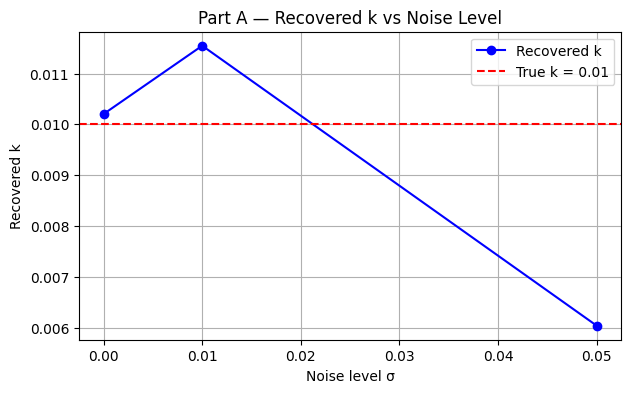

Noise σ       Recovered k   Rel. Error
0.00             0.010203        2.03%
0.01             0.011546       15.46%
0.05             0.006041       39.59%


In [11]:
plt.figure(figsize=(7, 4))
plt.plot(noise_levels, recovered_ks, 'bo-', label='Recovered k')
plt.axhline(y=k_true, color='red', linestyle='--', label=f'True k = {k_true}')
plt.xlabel('Noise level σ')
plt.ylabel('Recovered k')
plt.title('Part A — Recovered k vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

print("=" * 50)
print(f"{'Noise σ':<12} {'Recovered k':>12} {'Rel. Error':>12}")
print("=" * 50)
for sigma, k_rec in zip(noise_levels, recovered_ks):
    err = abs(k_rec - k_true) / k_true * 100
    print(f"{sigma:<12.2f} {k_rec:>12.6f} {err:>11.2f}%")
print("=" * 50)

### Part B Track Proposal

**Track chosen: Track A Inverse Problems & Parameter Identification**

**Project description:**
I will extend the Week 6 inverse problem to Burgers' equation, recovering the unknown
viscosity ν from 200 sparse noisy observations of u(x,t). The PINN will simultaneously
solve the forward problem and recover ν as a trainable scalar. I will implement a noise
sensitivity sweep (σ ∈ {0%, 1%, 5%, 10%}) and compare against a classical scipy
curve-fitting baseline.

**Reading plan:**
1. Raissi, Perdikaris, Karniadakis Part II (2017) — arXiv:1711.10566 — Section 4
2. Yang, Meng, Karniadakis — B-PINNs (2021) — arXiv:2003.06097 — Full
3. Yazdani et al. (2020) — Systems biology informed deep learning — Sections 1–2